<a href="https://colab.research.google.com/github/harada26009/TU_M_Math/blob/main/chap08_Cm_01.RandomForestClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import numpy.random as random
import scipy as sp
from pandas import Series,DataFrame
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline

import sklearn

%precision 3

'%.3f'

In [ ]:
import requests
import io
import pandas as pd
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
res = requests.get(url).content

adult = pd.read_csv(io.StringIO(res.decode('utf-8')),header=None)

adult.columns = ['age','workclass','fnlwgt','education','education-num','marital-status','occupation','relationship','race','sex','capital-gain','captal-loss','hours-per-week','native-country','flg-50K']

print('データの形式：{}'.format(adult.shape))
print('欠損の数：{}'.format(adult.isnull().sum().sum()))

adult.head()

データの形式：(32561, 15)
欠損の数：0


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,captal-loss,hours-per-week,native-country,flg-50K
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
adult.groupby('flg-50K').size()

,0
flg-50K,
<=50K,24720
>50K,7841


In [ ]:
adult['fin_fig']= adult['flg-50K'].map(lambda x: 1 if x ==' >50K' else 0)
adult.groupby('fin_fig').size()

,0
fin_fig,
0,24720
1,7841


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x = adult[['age','fnlwgt','education-num','capital-gain','captal-loss']]
y = adult['fin_fig']

X_train,X_test,y_train,y_test= train_test_split(x,y,test_size=0.5,random_state=0)

model=LogisticRegression()
model.fit(X_train,y_train)

print('正解率(train):{:.3f}'.format(model.score(X_train,y_train)))
print('正解率(test):{:.3f}'.format(model.score(X_test,y_test)))

正解率(train):0.796
正解率(test):0.799


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model.coef_

array([[-5.624e-03, -3.846e-06, -3.642e-02,  3.286e-04,  7.666e-04]])

In [ ]:
np.exp(model.coef_)

array([[0.994, 1.   , 0.964, 1.   , 1.001]])

練習問題8-2

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()
X_train,X_test,y_train,y_test = train_test_split(cancer.data,cancer.target,stratify=cancer.target,random_state=0)

model = LogisticRegression()
model.fit(X_train,y_train)
print('正解率(train):{:.3f}',format(model.score(X_train,y_train)))
print('正解率(test):{:.3f}',format(model.score(X_test,y_test)))

正解率(train):{:.3f} 0.960093896713615
正解率(test):{:.3f} 0.9300699300699301


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


練習問題8-3

In [ ]:
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

model = LogisticRegression()
model.fit(X_train_std,y_train)
print('正解率(train):{:.3f}',format(model.score(X_train_std,y_train)))
print('正解率(test):{:.3f}',format(model.score(X_test_std,y_test)))

正解率(train):{:.3f} 0.9906103286384976
正解率(test):{:.3f} 0.958041958041958


In [ ]:
# データを取得
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data'
res = requests.get(url).content

# 取得したデータをDataFrameオブジェクトとして読み込み
mushroom = pd.read_csv(io.StringIO(res.decode('utf-8')), header=None)

# データの列にラベルを設定
mushroom.columns = [
    'classes', 'cap_shape', 'cap_surface', 'cap_color', 'odor', 'bruises',
    'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color',
    'stalk_shape', 'stalk_root', 'stalk_surface_above_ring',
    'stalk_surface_below_ring', 'stalk_color_above_ring',
    'stalk_color_below_ring', 'veil_type', 'veil_color',
    'ring_number', 'ring_type', 'spore_print_color',
    'population', 'habitat'
]

# 先頭5行を表示
mushroom.head()

,classes,cap_shape,cap_surface,cap_color,odor,bruises,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
print('データの形式:{}'.format(mushroom.shape))
print('欠損の数:{}'.format(mushroom.isnull().sum().sum()))

データの形式:(8124, 23)
欠損の数:0


In [ ]:
mushroom_dummy = pd.get_dummies(mushroom[['gill_color','gill_attachment','cap_color']]).astype(int)
mushroom_dummy.head()

,gill_color_b,gill_color_e,gill_color_g,gill_color_h,gill_color_k,gill_color_n,gill_color_o,gill_color_p,gill_color_r,gill_color_u,...,cap_color_b,cap_color_c,cap_color_e,cap_color_g,cap_color_n,cap_color_p,cap_color_r,cap_color_u,cap_color_w,cap_color_y
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
mushroom_dummy['flg']= mushroom['classes'].map(lambda x: 1 if x=='p' else 0)

In [ ]:
mushroom_dummy.groupby(['cap_color_c','flg'])['flg'].count().unstack()

flg,0,1
cap_color_c,,
0,4176,3904
1,32,12


In [ ]:
mushroom_dummy.groupby(['gill_color_b','flg'])['flg'].count().unstack()

flg,0,1
gill_color_b,,
0,4208.0,2188.0
1,NaN,1728.0


In [ ]:
-(0.5*np.log2(0.5)+0.5*np.log2(0.5))

np.float64(1.0)

In [ ]:
-(0.001*np.log2(0.001)+0.999*np.log2(0.999))

np.float64(0.011407757737461138)

In [ ]:
def calc_entropy(p):
  return - (p*np.log2(p)+(1-p)*np.log2(1-p))

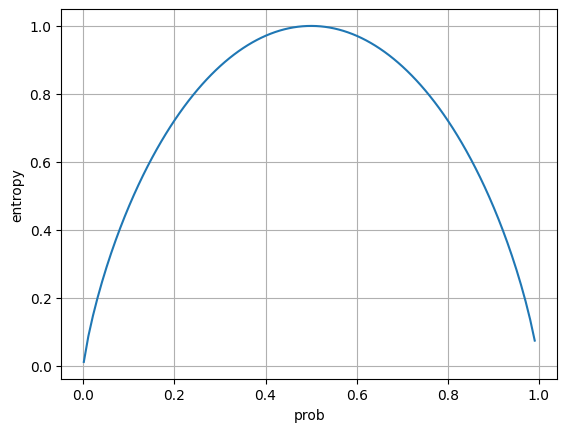

In [ ]:
p= np.arange(0.001,0.999,0.01)

plt.plot(p,calc_entropy(p))
plt.xlabel('prob')
plt.ylabel('entropy')
plt.grid(True)

In [ ]:
mushroom_dummy.groupby('flg')['flg'].count()

,flg
flg,
0,4208
1,3916


In [ ]:
entropy_init= -(0.518*np.log2(0.518)+0.482*np.log2(0.482))
print('毒キノコデータのエントロピーの初期値:{:.3f}'.format(entropy_init))

毒キノコデータのエントロピーの初期値:0.999


In [ ]:
mushroom_dummy.groupby(['cap_color_c','flg'])['flg'].count().unstack()

flg,0,1
cap_color_c,,
0,4176,3904
1,32,12


In [ ]:
p1=4176/(4176+3904)
p2=1-p1
entropy_c0 = -(p1*np.log2(p1)+p2*np.log2(p2))
print('entropy_c0:{:.3f}'.format(entropy_c0))

entropy_c0:0.999


In [ ]:
p1=32/(32+12)
p2=1-p1
entropy_c1 = -(p1*np.log2(p1)+p2*np.log2(p2))
print('entropy_c1:{:.3f}'.format(entropy_c1))

entropy_c1:0.845


In [ ]:
entropy_after = (4176+3904)/8124*entropy_c0 +(32+12)/8124*entropy_c1
print('データ分割後の平均エントロピー:{:.3f}'.format(entropy_after))

データ分割後の平均エントロピー:0.998


In [ ]:
print('変数cap_cplorの分割によって得られる情報有利:{:.3f}'.format(entropy_init-entropy_after))

変数cap_cplorの分割によって得られる情報有利:0.001


In [ ]:
mushroom_dummy.groupby(['gill_color_b', 'flg'])['flg'].count().unstack()

flg,0,1
gill_color_b,,
0,4208.0,2188.0
1,NaN,1728.0


In [ ]:
# gill_colorがbでない場合のエントロピー
p1 = 4208 / (4208 + 2188)
p2 = 2188 / (4208 + 2188)
entropy_b0 = -(p1 * np.log2(p1) + p2 * np.log2(p2))

# gill_colorがbである場合のエントロピー
p1 = 0 / (0 + 1728)
p2 = 1.0
entropy_b1 = -(p2 * np.log2(p2))

entropy_after = ((4208 + 2188) / 8124 * entropy_b0
                 + (0 + 1728) / 8124 * entropy_b1)

print('変数gill_colorの分割によって得られる情報利得：{:.3f}'
      .format(entropy_init - entropy_after))

変数gill_colorの分割によって得られる情報利得：0.269


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# データ分割
y = mushroom_dummy['flg']
X = mushroom_dummy.drop(['flg', 'cap_color_original'], axis=1) # cap_color_original列を削除
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=0
)

# 決定木クラスの初期化と学習
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=0
)
model.fit(X_train, y_train)

print('正解率(train):{:.3f}'.format(model.score(X_train, y_train)))
print('正解率(test):{:.3f}'.format(model.score(X_test, y_test)))

正解率(train):0.819
正解率(test):0.811


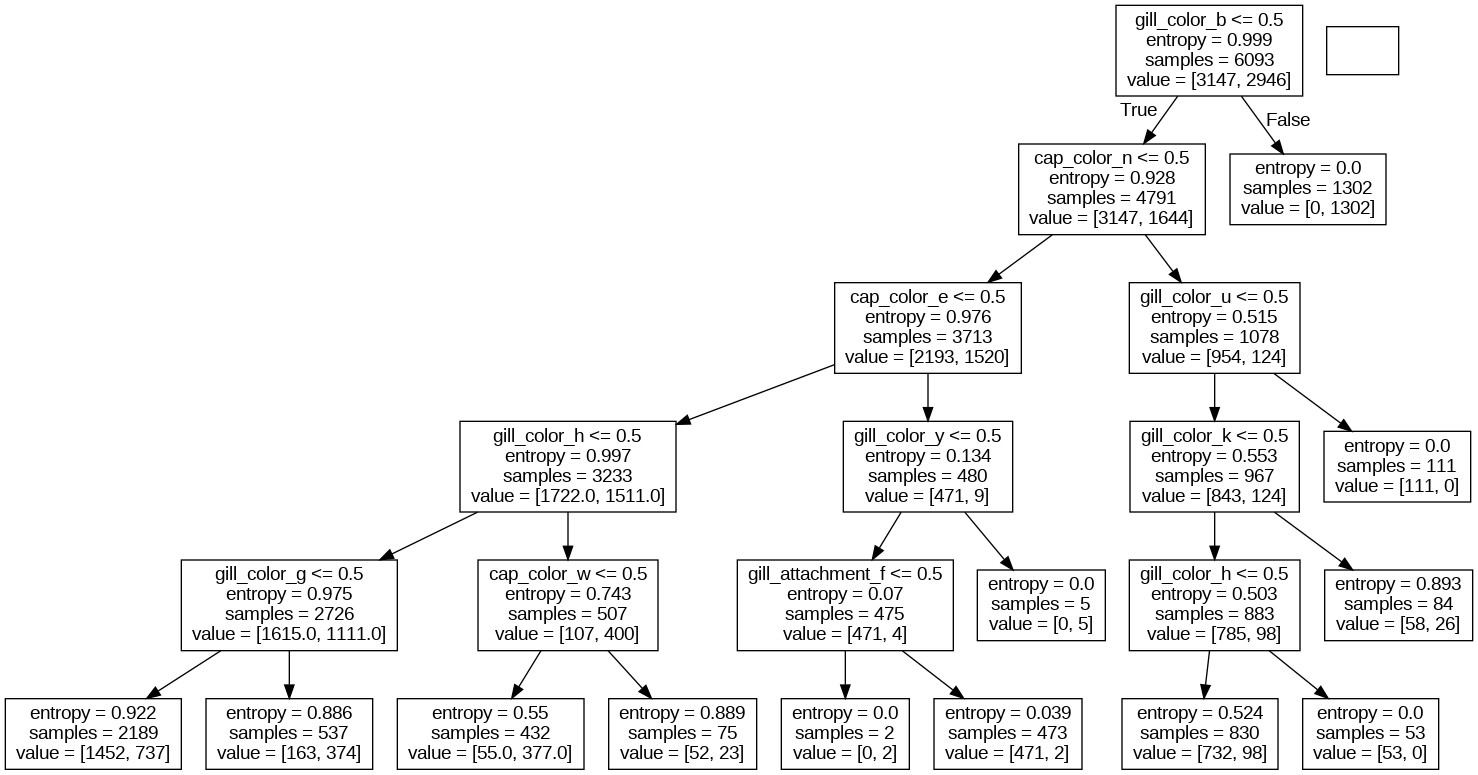

In [ ]:
from sklearn import tree
import pydotplus
from io import StringIO # Changed from sklearn.externals.six to io
from IPython.display import Image

dot_data = StringIO()
tree.export_graphviz(
    model,
    out_file=dot_data,
    feature_names=X.columns
)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [ ]:
from sklearn.tree import DecisionTreeClassifier

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target,
    stratify=cancer.target,
    random_state=66
)

models = {
    'tree1': DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0),
    'tree2': DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0),
    'tree3': DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=0),
    'tree4': DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0),
    'tree5': DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=0),
    'tree6': DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=0)
}

scores = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    scores[(model_name, 'train')] = model.score(X_train, y_train)
    scores[(model_name, 'test')] = model.score(X_test, y_test)

pd.Series(scores).unstack()


,test,train
tree1,0.930070,0.971831
tree2,0.902098,0.997653
tree3,0.902098,1.000000
tree4,0.923077,0.974178
tree5,0.895105,1.000000
tree6,0.895105,1.000000


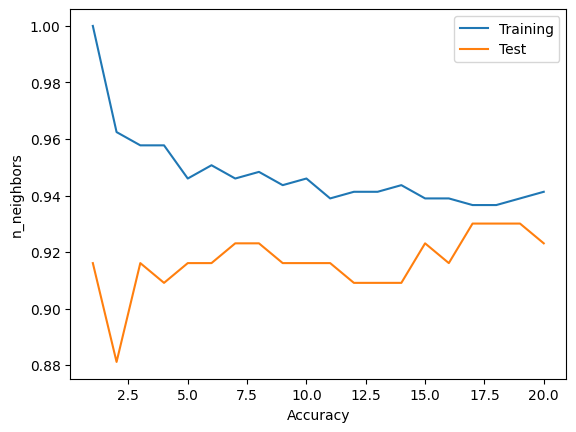

In [ ]:
# データやモデルを構築するためのライブラリをインポート
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# データセットの読み込み
cancer = load_breast_cancer()

# 訓練データとテストデータに分ける
# stratifyも層化抽出
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    stratify=cancer.target,
    random_state=0
)

# グラフ描画用のリストを用意
training_accuracy = []
test_accuracy = []

# 学習
for n_neighbors in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=n_neighbors)
    model.fit(X_train, y_train)

    training_accuracy.append(model.score(X_train, y_train))
    test_accuracy.append(model.score(X_test, y_test))

# グラフを描画
plt.plot(range(1, 21), training_accuracy, label='Training')
plt.plot(range(1, 21), test_accuracy, label='Test')
plt.xlabel('Accuracy')
plt.ylabel('n_neighbors')
plt.legend()

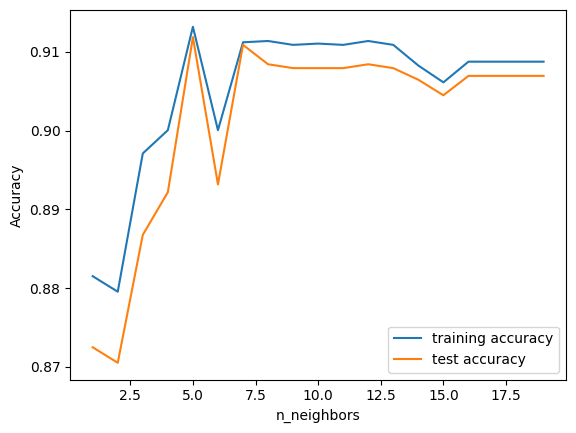

In [ ]:
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data'
res = requests.get(url).content

mush = pd.read_csv(io.StringIO(res.decode('utf-8')), header=None)
mush.columns = [
    'classes', 'cap_shape', 'cap_surface', 'cap_color', 'odor', 'bruises',
    'gill_attachment', 'gill_spacing', 'gill_size', 'gill_color', 'stalk_shape',
    'stalk_root', 'stalk_surface_above_ring', 'stalk_surface_below_ring',
    'stalk_color_above_ring', 'stalk_color_below_ring', 'veil_type', 'veil_color',
    'ring_number', 'ring_type', 'spore_print_color', 'population', 'habitat'
]

mush_dummy = pd.get_dummies(mush[['gill_color', 'gill_attachment', 'odor', 'cap_color']])
mush_dummy['flg'] = mush['classes'].map(lambda x: 1 if x == 'p' else 0)

from sklearn.neighbors import KNeighborsClassifier

# 説明変数と目的変数
X = mush_dummy.drop('flg', axis=1)
y = mush_dummy['flg']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=50)

training_accuracy = []
test_accuracy = []

neighbors_settings = range(1, 20)

for n_neighbors in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)
    training_accuracy.append(clf.score(X_train, y_train))
    test_accuracy.append(clf.score(X_test, y_test))

plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')

plt.ylabel('Accuracy')
plt.xlabel('n_neighbors')
plt.legend()


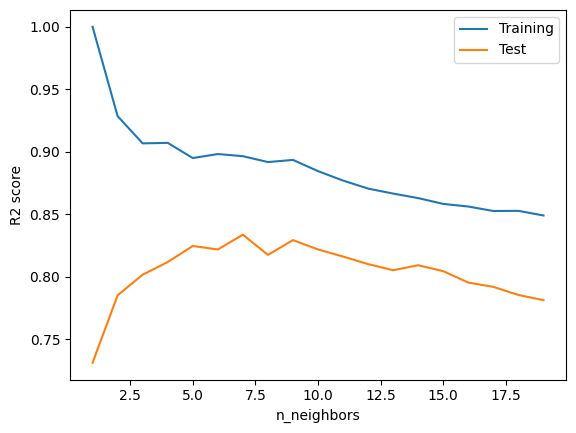

In [ ]:
#webからデータを取得したら、zipファイルを取り扱うためのライブラリ
import requests, zipfile
from io import StringIO
import io
#データがあるurlの確定
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00356/student.zip'

#データをurlから取得する
r =requests.get(url, stream=True)

#zipfileを読み込み展開する
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

student_data_math = pd.read_csv('student-mat.csv')
student_data_math = pd.read_csv('student-mat.csv',sep=';')
student_data_math.head()

student = pd.read_csv('student-mat.csv', sep=';')
X = student.loc[:,['age','Medu','Fedu','traveltime','studytime','failures','famrel','freetime','goout','Dalc','Walc','absences','G1','G2']].values # xをXに修正

from sklearn.neighbors import KNeighborsRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, student.G3, random_state=0
)

scores_train = []
scores_test = []

neighbors_settings = range(1, 20)

for n_neighbors in neighbors_settings:
    model = KNeighborsRegressor(n_neighbors=n_neighbors)
    model.fit(X_train, y_train)

    scores_train.append(model.score(X_train, y_train))
    scores_test.append(model.score(X_test, y_test))

plt.plot(neighbors_settings, scores_train, label='Training')
plt.plot(neighbors_settings, scores_test, label='Test')

plt.ylabel('R2 score')
plt.xlabel('n_neighbors')
plt.legend()

In [ ]:
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data,
    cancer.target,
    stratify=cancer.target,
    random_state=50
)

sc = StandardScaler()

sc.fit(X_train)

X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

model = SVC(kernel='rbf', random_state=0, C=2)

model.fit(X_train_std, y_train)

print('正解率(train):{:.3f}'.format(model.score(X_train_std, y_train)))
print('正解率(test):{:.3f}'.format(model.score(X_test_std, y_test)))

正解率(train):0.988
正解率(test):0.986


8-5をRandomForestClassifierに置き換えたもの

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target,
    stratify=cancer.target,
    random_state=66
)

models = {
    'forest1': RandomForestClassifier(criterion='entropy', max_depth=3, random_state=0),
    'forest2': RandomForestClassifier(criterion='entropy', max_depth=5, random_state=0),
    'forest3': RandomForestClassifier(criterion='entropy', max_depth=10, random_state=0),
    'forest4': RandomForestClassifier(criterion='gini', max_depth=3, random_state=0),
    'forest5': RandomForestClassifier(criterion='gini', max_depth=5, random_state=0),
    'forest6': RandomForestClassifier(criterion='gini', max_depth=10, random_state=0)
}

scores = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    scores[(model_name, 'train')] = model.score(X_train, y_train)
    scores[(model_name, 'test')] = model.score(X_test, y_test)

print(pd.Series(scores).unstack())

             test     train
forest1  0.951049  0.988263
forest2  0.951049  1.000000
forest3  0.958042  1.000000
forest4  0.937063  0.985915
forest5  0.951049  0.997653
forest6  0.958042  1.000000



用語　意味　どこで使うか
*   回帰　数値を予測する教師あり学習の手法。入力データから連続値を予測する。気温、売上、住宅価格、株価など数値を予測するとき。
*   分類　データをあらかじめ決められたクラスに分類する教師あり学習の手法。がんの良性・悪性判定、メールの迷惑メール判定、画像認識など。
*   教師あり学習　正解（ラベル）が付いたデータを学習し、新しいデータを予測する機械学習。回帰問題や分類問題全般。
*   重回帰分析　複数の説明変数から目的変数を線形で予測する回帰手法。売上予測、住宅価格予測、材料特性の予測など。
*   ロジスティック回帰分析　確率を計算して分類を行う手法。名前に「回帰」とあるが分類問題で使う。病気の有無、合格・不合格、購入・未購入など二値分類。
*   正則化　モデルが複雑になりすぎること（過学習）を防ぐために係数へ制約を加える手法。学習データには合うが未知データで精度が悪いとき。
*   リッジ回帰　L2正則化を用いた回帰。係数を小さくするが0にはしない。多重共線性があるデータや過学習を抑えたい回帰問題。
*   ラッソ回帰　L1正則化を用いた回帰。不要な特徴量の係数を0にして特徴選択も行う。特徴量が多く、重要な変数だけを選びたいとき。
*   決定木　条件分岐を繰り返して分類や回帰を行うモデル。分類・回帰の両方。結果が木構造で分かりやすい場合。
*   エントロピー　データの混ざり具合（不純度）を表す指標。値が小さいほどデータが純粋。決定木で分割する基準を決めるとき。
*   情報利得　分割によってエントロピーがどれだけ減少したかを示す値。決定木で最適な分割を選択するとき。
*   k-NN法　最も近いk個のデータを参考に分類・回帰する手法。学習はほとんど行わない。データ数が比較的少なく、似たデータから予測したいとき。
*   SVM　クラス間の境界（マージン）が最大となるように分類する手法。カーネル法で複雑な境界も扱える。画像認識、文字認識、医療診断など高精度な分類。
*   ノーフリーランチ　すべての問題で最も優れた機械学習アルゴリズムは存在しないという考え方。問題に応じて複数の手法を比較・選択するときの基本的な考え方。













